#### DATA loading

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("D:/Guvi/Projects/Final_project/Stock prediction/Data/AAPL.csv")
df = pd.DataFrame(data)
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.407747,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.386473,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.358108,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366972,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.377609,18362400.0
...,...,...,...,...,...,...,...
9818,2019-11-19,267.899994,268.000000,265.390015,266.290009,266.290009,19041800.0
9819,2019-11-20,265.540009,266.079987,260.399994,263.190002,263.190002,26558600.0
9820,2019-11-21,263.690002,264.010010,261.179993,262.010010,262.010010,30348800.0
9821,2019-11-22,262.589996,263.179993,260.839996,261.779999,261.779999,16331300.0


In [3]:
df.isna().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [4]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [5]:
df[df["Adj Close"].isna()]

,Date,Open,High,Low,Close,Adj Close,Volume
165,1981-08-10,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#soring the Nan's
df.dropna(inplace=True)

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"]

0      1980-12-12
1      1980-12-15
2      1980-12-16
3      1980-12-17
4      1980-12-18
          ...    
9818   2019-11-19
9819   2019-11-20
9820   2019-11-21
9821   2019-11-22
9822   2019-11-25
Name: Date, Length: 9822, dtype: datetime64[ns]

In [8]:
#getting the date time to Index:
df.set_index('Date', inplace=True)

In [9]:
years = df.index.year
months  = df.index.month

In [10]:
Yearly_avg = df.resample("YE").mean()
Monthly_avg = df.resample("ME").mean()

#### EDA

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

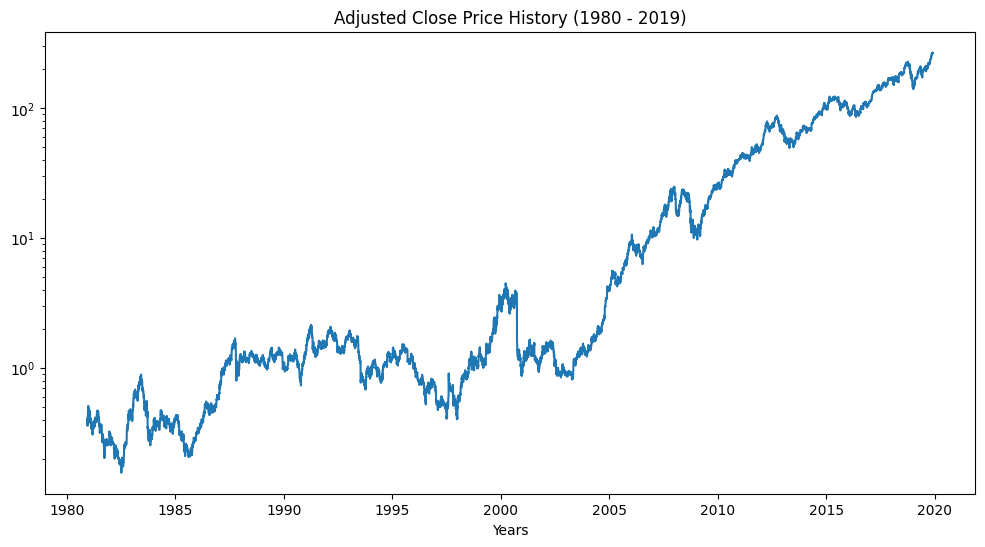

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df["Adj Close"])
plt.yscale("log")
plt.title("Adjusted Close Price History (1980 - 2019)")
plt.xlabel("Years")
plt.show()

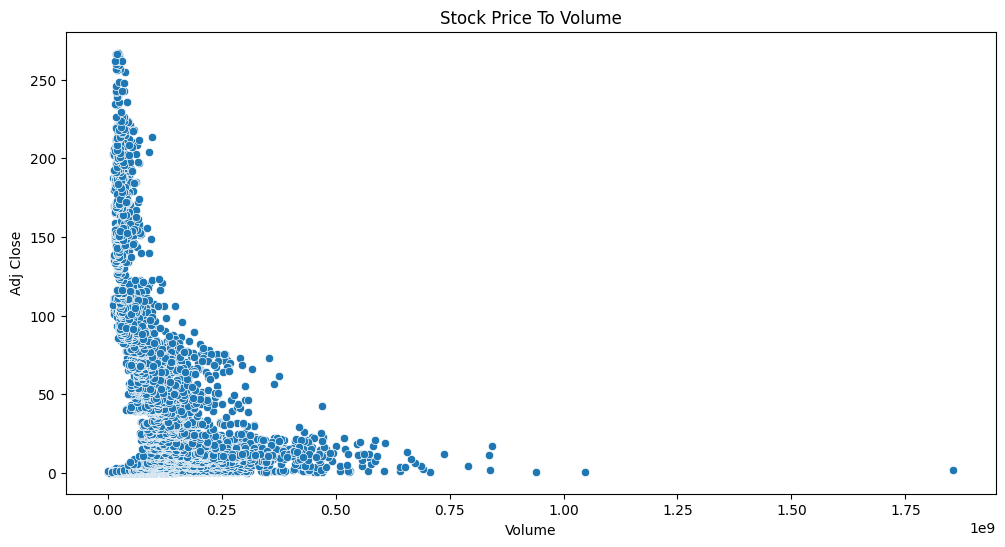

In [13]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=df["Volume"],y= df["Adj Close"])
plt.title("Stock Price To Volume")
plt.show()

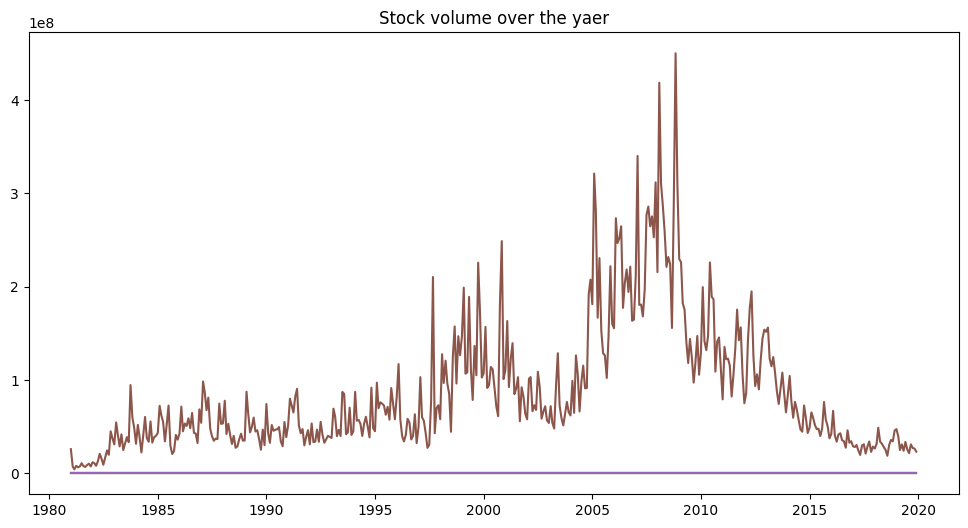

In [14]:
plt.figure(figsize=(12,6))
plt.plot(Monthly_avg)
plt.title("Stock volume over the yaer")
plt.show()

<Axes: >

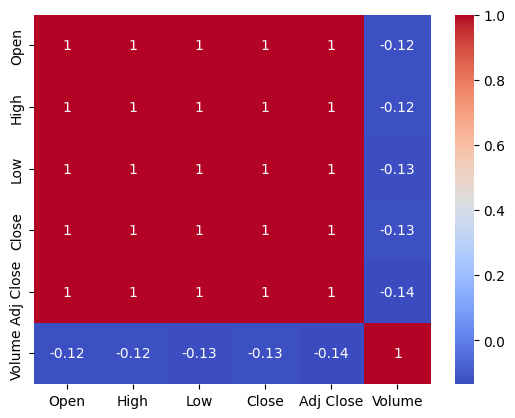

In [15]:
#checking co-relation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

#### Feature engg

In [16]:
#checking for stationary 

from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Adj Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value :{result[1]}")

ADF Statistic: 4.157321524818004
p-value :1.0


In [17]:
#Data transformation: using Logs 

df['Log_Adj_Return'] = np.log(df['Adj Close']).diff()
df['Log_Volume_Return'] = np.log(df['Volume']+1).diff()

In [18]:
df['Log_High_Ratio'] = np.log(df['High']/df['Close'])
df['Log_Low_Ratio'] = np.log(df['Low']/df['Close'])

In [19]:
#adding more features 

#Rolling Volatility:
df['Volatility_20'] = df['Log_Adj_Return'].rolling(20).std()
#Momentum:
df['Momentum_10'] = np.log(df['Adj Close']/df['Adj Close'].shift(10))
#MA Gap
df['MA_20'] = df['Adj Close'].rolling(20).mean()
df['MA_Gap_20'] = np.log(df['Adj Close']/df['MA_20'])

In [20]:
#daily Range:
df['Daily_Range'] = np.log(df['High']/df['Low'])

In [21]:
df.dropna(inplace=True)

In [22]:
df

,Open,High,Low,Close,Adj Close,Volume,Log_Adj_Return,Log_Volume_Return,Log_High_Ratio,Log_Low_Ratio,Volatility_20,Momentum_10,MA_20,MA_Gap_20,Daily_Range
Date,,,,,,,,,,,,,,,
1981-01-13,0.546875,0.546875,0.544643,0.544643,0.432566,5762400.0,-0.036223,-0.027793,0.004090,0.000000,0.045048,-0.165793,0.441519,-0.020486,0.004090
1981-01-14,0.546875,0.549107,0.546875,0.546875,0.434339,3572800.0,0.004090,-0.478004,0.004073,0.000000,0.043040,-0.137096,0.443912,-0.021802,0.004073
1981-01-15,0.558036,0.562500,0.558036,0.558036,0.443203,3516800.0,0.020203,-0.015798,0.007968,0.000000,0.038527,-0.088012,0.448167,-0.011138,0.007968
1981-01-16,0.555804,0.555804,0.553571,0.553571,0.439657,3348800.0,-0.008033,-0.048949,0.004026,0.000000,0.038600,-0.106973,0.451801,-0.027248,0.004026
1981-01-19,0.587054,0.589286,0.587054,0.587054,0.466250,10393600.0,0.058727,1.132588,0.003795,0.000000,0.039968,-0.026266,0.456233,0.021718,0.003795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-19,267.899994,268.000000,265.390015,266.290009,266.290009,19041800.0,-0.003037,-0.129560,0.006401,-0.003385,0.010875,0.038002,255.358114,0.041919,0.009786
2019-11-20,265.540009,266.079987,260.399994,263.190002,263.190002,26558600.0,-0.011710,0.332717,0.010921,-0.010657,0.011340,0.025865,256.395010,0.026157,0.021578
2019-11-21,263.690002,264.010010,261.179993,262.010010,262.010010,30348800.0,-0.004494,0.133403,0.007604,-0.003173,0.011492,0.009896,257.352966,0.017934,0.010777


#### Model

In [23]:
features = ['Log_Adj_Return',
       'Log_Volume_Return', 'Log_High_Ratio', 'Log_Low_Ratio','Volatility_20',
       'Momentum_10','MA_Gap_20', 'Daily_Range']

In [24]:
#split the model:

train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

In [25]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Log_Adj_Return',
       'Log_Volume_Return', 'Log_High_Ratio', 'Log_Low_Ratio', 'Volatility_20',
       'Momentum_10', 'MA_20', 'MA_Gap_20', 'Daily_Range'],
      dtype='object')

In [26]:
#scaling the log's on train set only 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(train[features])
X_test = scaler.transform(test[features])

y_train = train['Log_Adj_Return'].values
y_test = test['Log_Adj_Return'].values

In [27]:
#Sliding Window
def create_sequence(x,y, window=60):
    x_seq, y_seq = [],[]
    for i in range(window, len(x)):
        x_seq.append(x[i-window:i])
        y_seq.append(y[i])
    return np.array(x_seq), np.array(y_seq)

In [28]:
X_train_seq, y_train_seq = create_sequence(X_train, y_train)
X_test_seq, y_test_seq = create_sequence(X_test, y_test)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, Input

##### LSTM

In [30]:
#LSTM
def lstm_model(dropout_rate=0.2):
    model = Sequential([
        Input(shape=(X_train_seq.shape[1],X_train_seq.shape[2])),
        # LSTM(units=64, return_sequences=True),
        # Dropout(dropout_rate),
        LSTM(units=100, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1)
    ])
    return model

In [31]:
#compile:
from tensorflow.keras.optimizers import Adam

model = lstm_model()
model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error'
)

In [32]:
#Early stopping and modelCheckpoints:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor = 'val_loss',
    save_best_only = True
)

In [33]:
#model training:

history = model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=50, batch_size=32,
                    callbacks = [early_stop, checkpoint],
                    verbose=1)

Epoch 1/50


219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0077 - val_loss: 3.6450e-04
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0023 - val_loss: 3.4307e-04
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0019 - val_loss: 3.4327e-04
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0014 - val_loss: 4.1145e-04
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0013 - val_loss: 4.0639e-04
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0011 - val_loss: 3.3912e-04
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0012 - val_loss: 3.4264e-04
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0011 - val_loss: 3.4529e-04
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0013 - val_loss: 3.2992e-04
Epoch 10/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0011 - val_loss: 3.2649e-04
Epoch 11/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0010 - val_loss: 3.3097e-04
Epoch 12

In [34]:
#perdict:
y_pred = model.predict(X_test_seq)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [35]:
#evaluate:

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_seq, y_pred)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE :", rmse)

MSE : 0.00026301809119121084
RMSE : 0.016217832505955005


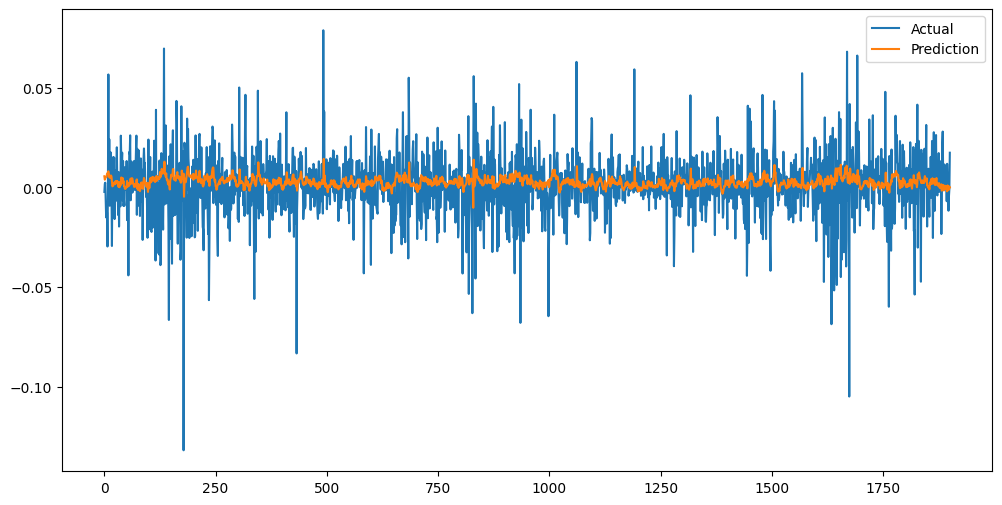

In [36]:
#poting 

plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label = "Actual")
plt.plot(y_pred, label = "Prediction")
plt.legend()
plt.show()

In [37]:
#comparing to baseline:
baseline = np.zeros_like(y_test_seq)
baseline_mse = mean_squared_error(y_test_seq, baseline)
baseline_rmse = np.sqrt(baseline_mse)

print('Baseline RMSE :', baseline_rmse)

Baseline RMSE : 0.016034004944689755


In [38]:
#inverse the prices:
last_price = test['Adj Close'].values[60-1:-1]
actual_price = test['Adj Close'].values[61:]
predicted_prices = last_price*np.exp(y_pred.flatten())

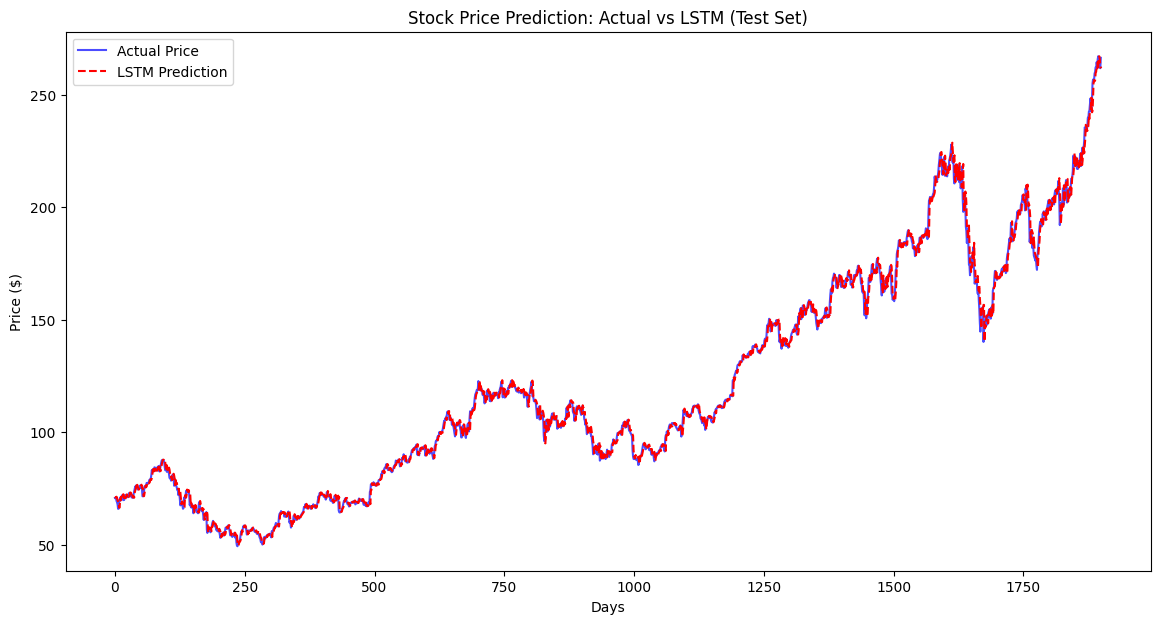

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(actual_price, label='Actual Price', color='blue', alpha=0.7)
plt.plot(predicted_prices, label='LSTM Prediction', color='red', linestyle='--')
plt.title('Stock Price Prediction: Actual vs LSTM (Test Set)')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

##### Tuning LSTM

In [40]:
#tuning:
import keras_tuner as kt

def tune_model(hp):
    model = Sequential()

    model.add(LSTM(
        units = hp.Int('units', min_value=32, max_value=128, step = 32),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ))

    model.add(Dropout(
        hp.Float('dropout', 0.1,0.5, step=0.1)
    ))

    model.add(Dense(1))

    model.compile(
        optimizer = Adam(hp.Choice('lr', [1e-2,1e-3,1e-4])),
        loss = 'mse'
    )

    return model

In [41]:
tuner = kt.RandomSearch(tune_model,objective='val_loss', max_trials=10)
tuner.search(X_test_seq, y_train_seq, epochs =20, validation_split=0.2)

Reloading Tuner from .\untitled_project\tuner0.json


In [42]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hp.values)

{'units': 128, 'dropout': 0.5, 'lr': 0.0001}


In [43]:
best_model = tuner.hypermodel.build(best_hp)

c:\Users\TEMP\Anaconda\envs\stat_viz\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
#training:
history_tuned = best_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split= 0.2,
    epochs=50,
    batch_size = 32, 
    callbacks = early_stop,
    verbose = 1
    
)

Epoch 1/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0289 - val_loss: 9.3786e-04
Epoch 2/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0141 - val_loss: 8.1142e-04
Epoch 3/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0102 - val_loss: 6.8059e-04
Epoch 4/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0075 - val_loss: 6.3530e-04
Epoch 5/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0062 - val_loss: 6.5579e-04
Epoch 6/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0054 - val_loss: 6.7040e-04
Epoch 7/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0044 - val_loss: 6.3710e-04
Epoch 8/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0042 - val_loss: 6.2207e-04
Epoch 9/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0037 - val_loss: 5.9562e-04
Epoch 10/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0032 - val_loss: 6.0444e-04
Epoch 11/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0030 - val_loss: 5.9664e-

In [45]:
y_pred_tuned = best_model.predict(X_test_seq)

mse = mean_squared_error(y_test_seq, y_pred)
rmse = np.sqrt(mse)

print("Tuned LSTM Test MSE:", mse)
print("Tuned LSTM Test RMSE:", rmse)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Tuned LSTM Test MSE: 0.00026301809119121084
Tuned LSTM Test RMSE: 0.016217832505955005


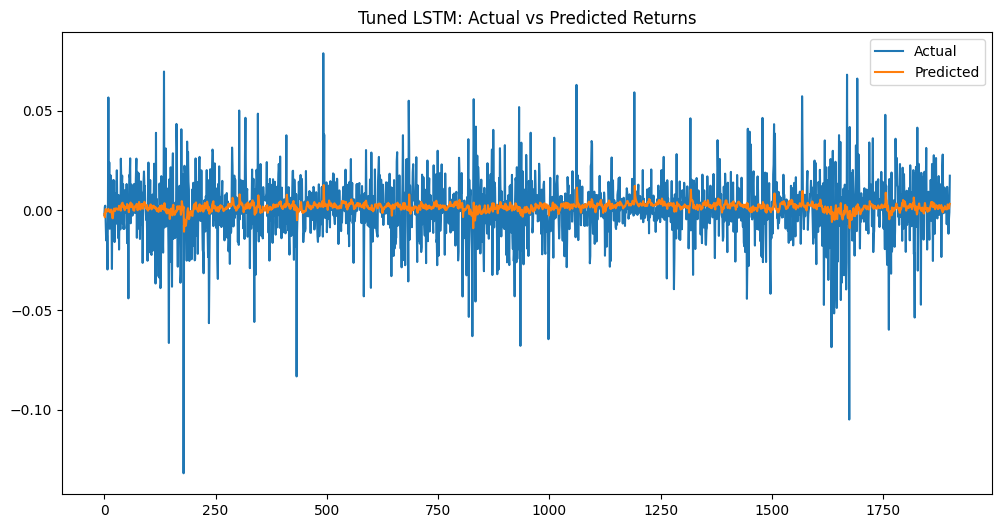

In [46]:
plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label="Actual")
plt.plot(y_pred_tuned, label="Predicted")
plt.legend()
plt.title("Tuned LSTM: Actual vs Predicted Returns")
plt.show()

##### RNN 

In [47]:
#RNN
def rnn_model(units= 50, dropout_rate=0.2):
    model = Sequential([
        SimpleRNN(units, return_sequences=False, 
                  input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(dropout_rate),
        Dense(1)
    ])
    return model

In [48]:
model = rnn_model()
model.compile(optimizer=Adam(learning_rate=0.005), 
              loss = 'mse')

c:\Users\TEMP\Anaconda\envs\stat_viz\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
rnn_history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split = 0.1,
    epochs =50,
    batch_size =32,
    callbacks = [early_stop, checkpoint],
    verbose = 1
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1411 - val_loss: 8.1403e-04
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035 - val_loss: 3.9206e-04
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - val_loss: 3.9451e-04
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 3.7368e-04
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 3.5352e-04
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - val_loss: 3.6815e-04
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - val_loss: 3.6001e-04
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - val_loss: 3.4995e-04
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 4.8110e-04
Epoch 10/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 4.0066e-04
Epoch 11/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - val_loss: 4.4556e-04
Epoch 12

In [50]:
y_pred_rnn = model.predict(X_test_seq)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [51]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_seq, y_pred)


print("MSE :", mse)

MSE : 0.00026301809119121084


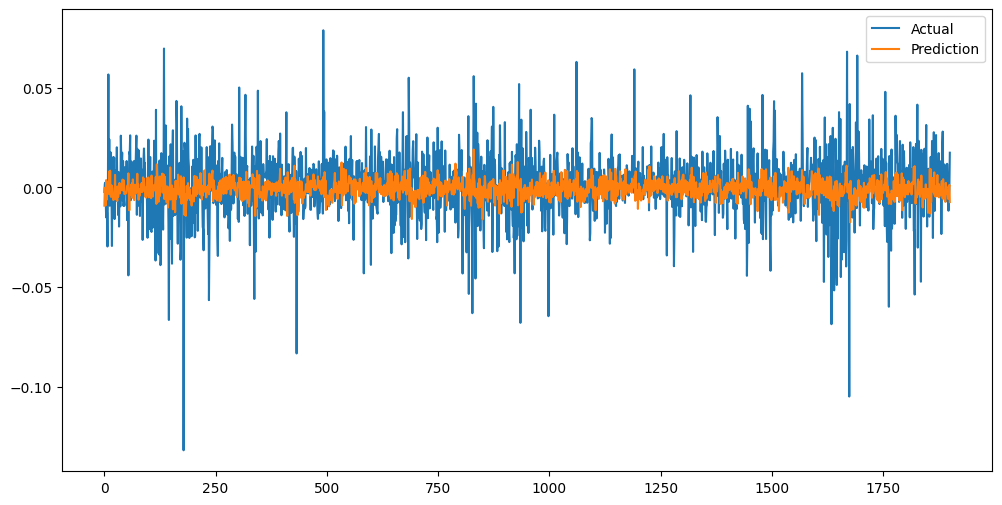

In [52]:
plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label = "Actual")
plt.plot(y_pred_rnn, label = "Prediction")
plt.legend()
plt.show()

In [53]:
#inverse the prices:
last_price_rnn = test['Adj Close'].values[60-1:-1]
actual_price_rnn = test['Adj Close'].values[61:]
predicted_prices_rnn = last_price*np.exp(y_pred.flatten())

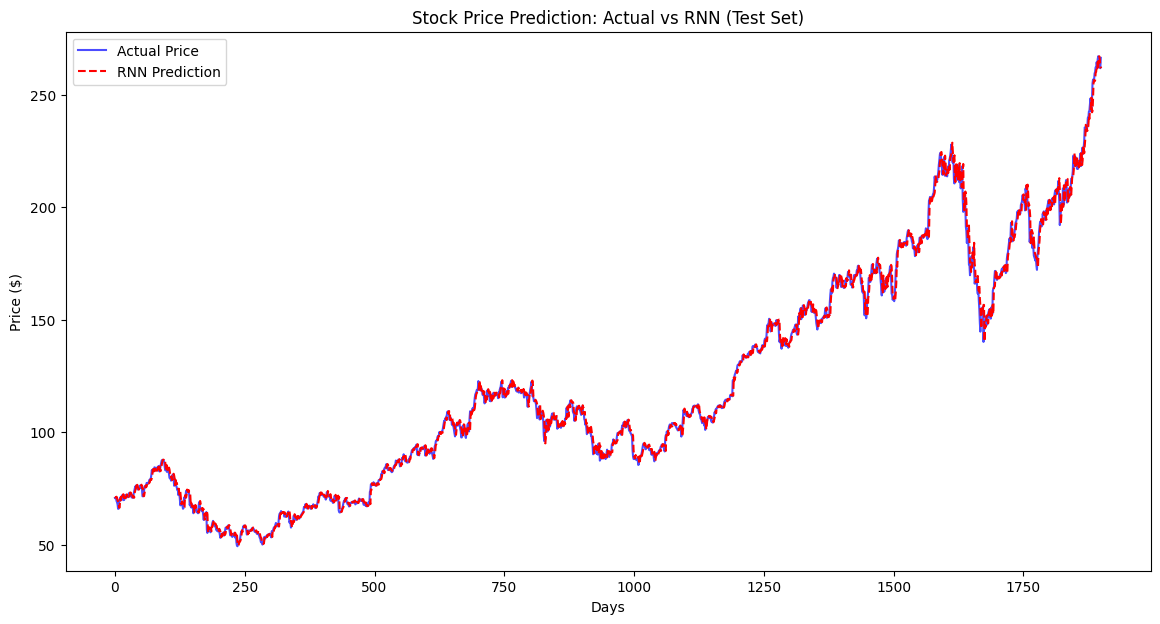

In [54]:
plt.figure(figsize=(14, 7))
plt.plot(actual_price_rnn, label='Actual Price', color='blue', alpha=0.7)
plt.plot(predicted_prices_rnn, label='RNN Prediction', color='red', linestyle='--')
plt.title('Stock Price Prediction: Actual vs RNN (Test Set)')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [55]:
#Sequenec for 5 days 10 days predictions:

def create_sequence_multi(x, y, Window=60, days = 5):
    x_days, y_days = [], []

    for i in range(Window, len(x)-days+1):
        x_days.append(x[i-Window:i])
        y_days.append(y[i:i+days])

    return np.array(x_days), np.array(y_days)

In [62]:
X_train_days , y_train_days = create_sequence_multi(X_train, y_train, Window=60, days=5)
X_test_days, y_test_days = create_sequence_multi(X_test, y_test, Window=60, days=5)

In [63]:
#LSTM 
model_lstm = Sequential([
    LSTM(128, input_shape=(X_train_days.shape[1], X_train_days.shape[2])),
    Dropout(0.5),
    Dense(5)   # 5 outputs for 5 days
])

model_lstm.compile(
    optimizer=Adam(0.0001),
    loss="mse"
)

In [64]:
history = model_lstm.fit(
    X_train_days,
    y_train_days,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose =1
)

Epoch 1/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0263 - val_loss: 0.0012
Epoch 2/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0118 - val_loss: 8.6462e-04
Epoch 3/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0085 - val_loss: 7.7726e-04
Epoch 4/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0067 - val_loss: 7.1800e-04
Epoch 5/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0057 - val_loss: 6.7329e-04
Epoch 6/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0046 - val_loss: 6.5743e-04
Epoch 7/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0041 - val_loss: 6.4967e-04
Epoch 8/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0036 - val_loss: 6.2787e-04
Epoch 9/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0033 - val_loss: 6.2567e-04
Epoch 10/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0030 - val_loss: 6.1279e-04
Epoch 11/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0027 - val_loss: 6.2183e-04
E

In [65]:
y_pred_days = model_lstm.predict(X_test_days)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [68]:
sample_index = 0 
last_price = test['Adj Close'].values[60+sample_index-1]
pred_returns = y_pred_days[sample_index]

In [69]:
pred_prices = []
current_price = last_price

for r in pred_returns:
    current_price = current_price*np.exp(r)
    pred_prices.append(current_price)

print('Predicted 5-days Price :', pred_prices)

Predicted 5-days Price : [np.float64(70.36363987092233), np.float64(70.29825960866977), np.float64(70.20933305710872), np.float64(70.16292359897197), np.float64(70.29456573250881)]


In [75]:
#RNN 

model_rnn = Sequential([
    SimpleRNN(128, input_shape = (X_train_days.shape[1], X_train_days.shape[2])),
    Dropout(0.5),
    Dense(5)
])

model_rnn.compile(
    optimizer = Adam(0.0001),
    loss = 'mse'
)

c:\Users\TEMP\Anaconda\envs\stat_viz\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [76]:
history = model_rnn.fit(
    X_train_days,
    y_train_days,
    validation_split = 0.2,
    epochs =50, 
    batch_size = 32,
    callbacks = [early_stop]

)

Epoch 1/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5634 - val_loss: 0.0368
Epoch 2/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3214 - val_loss: 0.0194
Epoch 3/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2388 - val_loss: 0.0119
Epoch 4/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1867 - val_loss: 0.0084
Epoch 5/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1501 - val_loss: 0.0057
Epoch 6/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1253 - val_loss: 0.0046
Epoch 7/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0985 - val_loss: 0.0038
Epoch 8/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0904 - val_loss: 0.0029
Epoch 9/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0741 - val_loss: 0.0024
Epoch 10/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0621 - val_loss: 0.0021
Epoch 11/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0558 - val_loss: 0.0018
Epoch 12/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

In [79]:
y_pred_days = model_rnn.predict(X_test_days)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [80]:
sample_index = 0 
last_price = test['Adj Close'].values[60+sample_index-1]
pred_returns = y_pred_days[sample_index]

pred_prices = []
current_price = last_price

for r in pred_returns:
    current_price = current_price*np.exp(r)
    pred_prices.append(current_price)

print('Predicted 5-days Price :', pred_prices)

Predicted 5-days Price : [np.float64(70.7351109818133), np.float64(70.7677354821343), np.float64(70.53685855943064), np.float64(70.62852964860478), np.float64(71.01027326259506)]


In [81]:
#actual prices:

actual_prices = test['Adj Close'].values[60+sample_index: 60+sample_index+5]
print("Actual 5 day prices :", actual_prices)

Actual 5 day prices : [70.624855 70.749161 70.915718 70.442146 69.386826]
